# Predicción del Éxito Comercial de Videojuegos en Steam
### Un enfoque de Ciencia de Datos aplicado al análisis de mercados digitales

**Autor:** Mateo García Guerrero
**Programa:** Maestría en Ciencia de Datos y Maquinas de aprendizaje
**Proyecto aplicado — Parte 2: Sistema de Análisis Predictivo o de Clasificación**

---

## 1. Planteamiento del problema

La industria de videojuegos digitales, con Steam como su plataforma dominante, mueve miles
de millones de dólares al año y publica más de 10.000 títulos nuevos anualmente. Desde una
perspectiva económica, cada lanzamiento es una decisión de mercado bajo incertidumbre:
¿qué combinación de precio, género y características del producto predice el éxito comercial?

**Pregunta de investigación:** ¿Es posible predecir, a partir de características observables
al momento del lanzamiento (precio, género, plataformas, desarrolladora, etc.), si un
videojuego alcanzará un nivel de éxito comercial (medido por número estimado de propietarios
y proporción de reseñas positivas)?<>

## 2. Objetivos

- **General:** Desarrollar un modelo de clasificación que prediga el éxito comercial de un
  videojuego en Steam a partir de sus características de lanzamiento.
- **Específicos:**
  1. Realizar un análisis exploratorio de datos (EDA) con enfoque de mercado: precio por
     género, evolución temporal de lanzamientos, relación entre precio y "owners".
  2. Construir y evaluar modelos de clasificación (Regresión Logística y Random Forest).
  3. Interpretar los resultados e identificar los factores más relevantes del éxito comercial.
  4. Discutir las implicaciones éticas y las limitaciones del uso de estos datos.

## 3. Ética, privacidad y uso responsable de los datos

- Los datos utilizados son **agregados y públicos** (metadata de juegos, no datos personales
  de usuarios individuales).

## 4. Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests 
import time
import ast
import warnings
import statsmodels.api as sm
import kagglehub
from kagglehub import KaggleDatasetAdapter
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# Cargar la Base de Datos de Kaggle
# df = pd.read_csv(r"C:/Users/Mateo/Desktop/Code/Proyecto Mateo Garcia/Bases_de_datos/games.csv", header=0)
# Base de datos y Video: https://drive.google.com/drive/folders/1Ce_QJmCDmDlUTSm4Ip4UtyPWf6Ex_J9-?usp=sharing 
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "fronkongames/steam-games-dataset",
    "games.csv"
)

## 5. Adquisición de datos

### 5.1 Dataset histórico-actualizado (Kaggle)

Usamos **"Steam Games Dataset"** de FronkonGames
(https://www.kaggle.com/datasets/fronkongames/steam-games-dataset), generado directamente
con la Steam Web API + SteamSpy y **actualizado periódicamente** (85.000+ juegos, incluye
lanzamientos recientes) — a diferencia de datasets estáticos más antiguos.

In [7]:
# El Id de los juegos de Steam es único, por lo que se puede usar como índice del DataFrame.
df.index.name = "Appid"
print(df.columns.tolist())


['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU', 'Required age', 'Price', 'DiscountDLC count', 'About the game', 'Supported languages', 'Full audio languages', 'Reviews', 'Header image', 'Website', 'Support url', 'Support email', 'Windows', 'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score', 'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations', 'Notes', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks', 'Developers', 'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']


In [8]:
# Se ordeno las columnas  de forma correcta
cols = df.columns.tolist()

idx_price = cols.index('Price')

tramo = cols[0:idx_price+1]        
tramo_movido = tramo[1:] + ['Discount']   

cols_nuevo = tramo_movido + cols[idx_price+1:]
df.columns = cols_nuevo

df.rename(columns={'DiscountDLC count': 'dlc_count'}, inplace=True)
df.columns = df.columns.str.replace(" ", "_").str.lower()
print(df.columns.tolist())
display(df)

['name', 'release_date', 'estimated_owners', 'peak_ccu', 'required_age', 'price', 'discount', 'dlc_count', 'about_the_game', 'supported_languages', 'full_audio_languages', 'reviews', 'header_image', 'website', 'support_url', 'support_email', 'windows', 'mac', 'linux', 'metacritic_score', 'metacritic_url', 'user_score', 'positive', 'negative', 'score_rank', 'achievements', 'recommendations', 'notes', 'average_playtime_forever', 'average_playtime_two_weeks', 'median_playtime_forever', 'median_playtime_two_weeks', 'developers', 'publishers', 'categories', 'genres', 'tags', 'screenshots', 'movies']


,name,release_date,estimated_owners,peak_ccu,required_age,price,discount,dlc_count,about_the_game,supported_languages,...,average_playtime_two_weeks,median_playtime_forever,median_playtime_two_weeks,developers,publishers,categories,genres,tags,screenshots,movies
Appid,,,,,,,,,,,,,,,,,,,,,
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3249570,Sotsugyo Omedeto,"Mar 1, 2026",0 - 0,0,0,8.09,0,0,A survival trial game set in an all-girls scho...,"['English', 'Japanese', 'Korean', 'Simplified ...",...,0,0,0,SuperLoki,SuperLoki,"Single-player,Steam Achievements,Camera Comfor...","Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2218150,Island on cloud,"Feb 24, 2026",0 - 0,0,0,0.59,0,0,"A game with a quirky art style, resembling ani...","['English', 'Simplified Chinese']",...,0,0,0,7th Ghost,7th Ghost,"Single-player,Family Sharing","Adventure,RPG",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3788650,Rosie Planet,"Mar 1, 2026",0 - 0,0,0,12.99,0,0,Jam Packed full with Videogame Rosie Planet is...,['English'],...,0,0,0,Connor Leary,Connor Leary,"Single-player,Full controller support,Playable...","Action,Adventure,Indie",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


## 6. Limpieza de datos

In [9]:
# Revisión de valores nulos y tipos
print(df.isnull().sum().sort_values(ascending=False).head(10))
display(df.dtypes.head(20))


movies            125855
score_rank        125815
metacritic_url    121597
reviews           113674
notes             102545
website            75335
support_url        70560
tags               42502
support_email      22630
categories          8966
dtype: int64


name                        str
release_date                str
estimated_owners            str
peak_ccu                  int64
required_age              int64
price                   float64
discount                  int64
dlc_count                 int64
about_the_game              str
supported_languages         str
full_audio_languages        str
reviews                     str
header_image                str
website                     str
support_url                 str
support_email               str
windows                    bool
mac                        bool
linux                      bool
metacritic_score          int64
dtype: object

In [10]:
# Función auxiliar: las columnas 'genres' y 'categories' pueden venir como texto separado
# por comas o como una representación de lista de Python (ej. "['Action', 'Indie']").
# Esta función lo normaliza a una lista real de Python, sin importar el formato.
def parse_list_field(x):
    if pd.isna(x):
        return []
    x = str(x).strip()
    if x.startswith("[") and x.endswith("]"):
        try:
            return [str(i).strip() for i in ast.literal_eval(x)]
        except Exception:
            pass
    return [g.strip() for g in x.split(",") if g.strip()]

# Función auxiliar: 'estimated_owners' viene como texto tipo "0 - 20000" o "20000-50000"
def owners_midpoint(x):
    try:
        parts = str(x).replace(",", "").split("-")
        low, high = float(parts[0].strip()), float(parts[1].strip())
        return (low + high) / 2
    except Exception:
        return np.nan


In [11]:
df = df.copy()
filas_antes = df.shape[0]

# Convertir fecha
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

# Filtrar precios y años inválidos
df = df[(df["price"] >= 0) & (df["release_year"] >= 2005)]

# Total de reseñas y proporción positiva
df["total_ratings"] = df["positive"] + df["negative"]
df = df[df["total_ratings"] > 0]  # descartar juegos sin reseñas
df["positive_ratio"] = df["positive"] / df["total_ratings"]

# Owners: convertir "estimated_owners" (rango de texto) a punto medio numérico
df["owners_mid"] = df["estimated_owners"].apply(owners_midpoint)
df.dropna(subset=["owners_mid"], inplace=True)

# Listas normalizadas de género y categorías
df["genre_list"] = df["genres"].apply(parse_list_field)

print("Filas antes:", filas_antes, "| Filas después de limpieza:", df.shape[0])
df.head()


Filas antes: 125855 | Filas después de limpieza: 82935


,name,release_date,estimated_owners,peak_ccu,required_age,price,discount,dlc_count,about_the_game,supported_languages,...,categories,genres,tags,screenshots,movies,release_year,total_ratings,positive_ratio,owners_mid,genre_list
Appid,,,,,,,,,,,,,,,,,,,,,
496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN,2016,255,0.988235,10000.0,[Adventure]
1034400,Mystery Solitaire The Black Raven,2019-05-06,0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN,2019,24,0.875000,10000.0,[Casual]
1934300,Armored Brigade II,2025-04-08,0 - 20000,8,0,35.99,10,1,Building on the success of its acclaimed prede...,['English'],...,"Single-player,Steam Workshop,Steam Cloud,Famil...","Simulation,Strategy","Simulation,Strategy,RTS,Wargame,Grand Strategy...",https://shared.akamai.steamstatic.com/store_it...,NaN,2025,130,0.900000,10000.0,"[Simulation, Strategy]"
1157670,Hepta Beats,2021-05-07,0 - 20000,0,0,0.99,0,0,Hepta Beats is a 2D side-view platformer game ...,"['English', 'French', 'Italian', 'German', 'Sp...",...,"Single-player,Steam Achievements,Full controll...","Casual,Indie","Precision Platformer,Rhythm,Music,Difficult,Ab...",https://shared.akamai.steamstatic.com/store_it...,NaN,2021,32,0.875000,10000.0,"[Casual, Indie]"
1540330,MUMBA IV: Egypt Jewels,2021-12-13,0 - 20000,1,0,0.59,0,1,WARRNING Don't show Your mom this game. You kn...,"['English', 'French', 'Italian', 'German', 'Sp...",...,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie,Strategy","Casual,Action,Strategy,Puzzle,Match 3,Singlepl...",https://shared.akamai.steamstatic.com/store_it...,NaN,2021,25,0.760000,10000.0,"[Action, Casual, Indie, Strategy]"


## 7. Análisis Exploratorio de Datos (EDA)

Incluye tanto exploración estándar de ciencia de datos como una lectura de mercado
(perspectiva económica): distribución de precios, géneros dominantes, y relación
precio–demanda (proxy) por género.


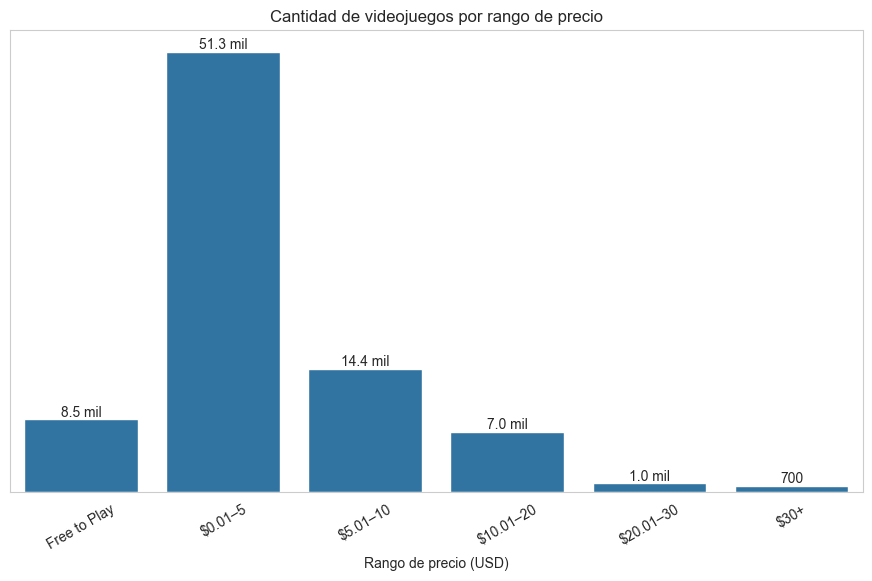

In [12]:
bins = [
    -0.01,
    0,
    5,
    10,
    20,
    30,
    1000
]

labels = [
    "Free to Play",
    "$0.01–5",
    "$5.01–10",
    "$10.01–20",
    "$20.01–30",
    "$30+"
]

df["price_range"] = pd.cut(
    df["price"],
    bins=bins,
    labels=labels
)

plt.figure(figsize=(11, 6))

ax = sns.countplot(
    data=df,
    x="price_range",
    order=labels
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x/1000:.1f} mil" if x >= 1000 else f"{x:.0f}"
    )

plt.title("Cantidad de videojuegos por rango de precio")
plt.xlabel("Rango de precio (USD)")
plt.ylabel("Número de videojuegos")
plt.yticks([])
plt.ylabel("")
plt.xticks(rotation=30)

plt.show()

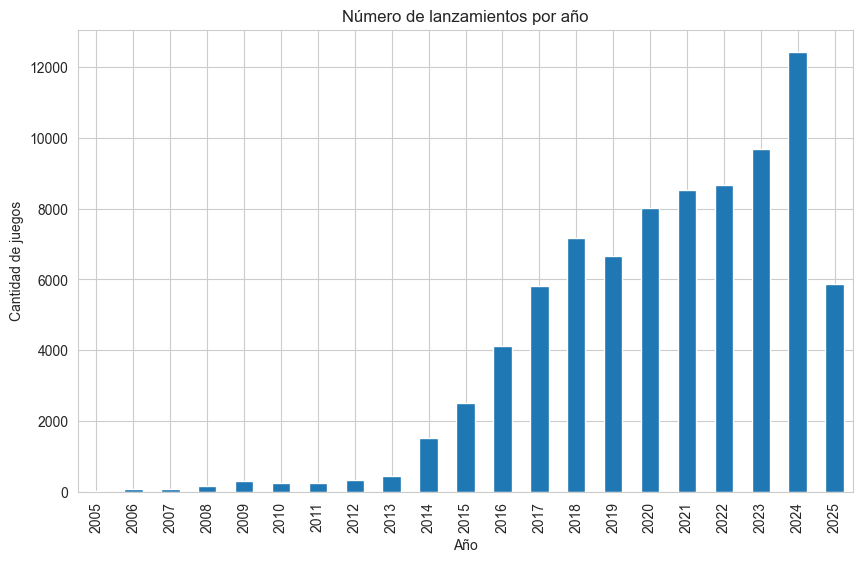

In [13]:
# Lanzamientos por año
plt.figure()
df["release_year"].value_counts().sort_index().plot(kind="bar")
plt.title("Número de lanzamientos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de juegos")
plt.show()


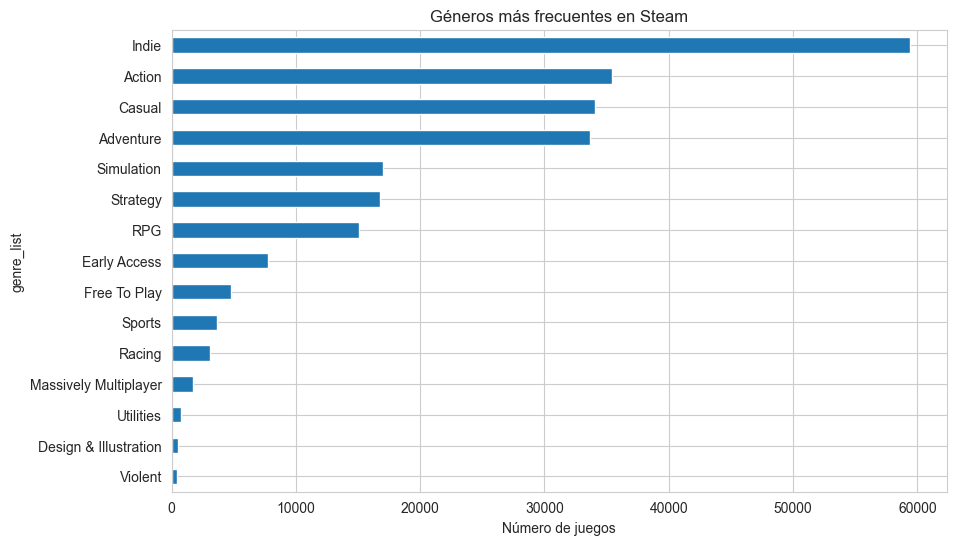

In [14]:
# Géneros más comunes
all_genres = df["genre_list"].explode()
top_genres = all_genres.value_counts().head(15)

plt.figure()
top_genres.plot(kind="barh")
plt.title("Géneros más frecuentes en Steam")
plt.xlabel("Número de juegos")
plt.gca().invert_yaxis()
plt.show()


In [15]:
# Enfoque de mercado: precio y dueños por género (top 10 géneros)
df_exp = df.explode("genre_list")
top10 = top_genres.head(10).index
market_by_genre = (df_exp[df_exp["genre_list"].isin(top10)]
                    .groupby("genre_list")
                    .agg(precio_mediana=("price", "median"),
                         precio_promedio=("price", "mean"),
                         precio_p25=("price", lambda x: x.quantile(0.25)),
                         precio_p75=("price", lambda x: x.quantile(0.75)),
                         precio_max=("price", "max"),
                         owners_mediana=("owners_mid", "median"),
                         owners_promedio=("owners_mid", "mean"),
                         owners_p25=("owners_mid", lambda x: x.quantile(0.25)),
                         owners_p75=("owners_mid", lambda x: x.quantile(0.75)),
                         owners_max=("owners_mid", "max"),
                         n_juegos=("name", "count"))
                    .sort_values("owners_mediana", ascending=False))
market_by_genre


,precio_mediana,precio_promedio,precio_p25,precio_p75,precio_max,owners_mediana,owners_promedio,owners_p25,owners_p75,owners_max,n_juegos
genre_list,,,,,,,,,,,
Free To Play,0.00,0.088848,0.00,0.00,29.99,35000.0,478466.792770,10000.0,75000.0,150000000.0,4758
Action,2.99,5.337135,0.99,5.99,999.00,10000.0,182914.081011,10000.0,35000.0,150000000.0,35452
Adventure,2.99,5.345304,0.99,6.04,500.00,10000.0,130020.188226,10000.0,35000.0,150000000.0,33683
Casual,2.09,4.443110,0.99,4.99,500.00,10000.0,55904.344255,10000.0,10000.0,75000000.0,34091
Early Access,4.99,7.586692,1.99,9.99,199.99,10000.0,79099.922740,10000.0,10000.0,75000000.0,7766
Indie,2.69,4.624349,0.99,5.09,999.98,10000.0,76644.464280,10000.0,35000.0,75000000.0,59378
RPG,3.99,6.199016,1.19,7.99,199.99,10000.0,181992.516061,10000.0,35000.0,75000000.0,15099
Simulation,3.49,6.663687,0.99,7.99,999.98,10000.0,118344.396147,10000.0,35000.0,35000000.0,17024
Sports,2.99,7.619989,0.99,7.99,199.99,10000.0,109952.535937,10000.0,35000.0,35000000.0,3687


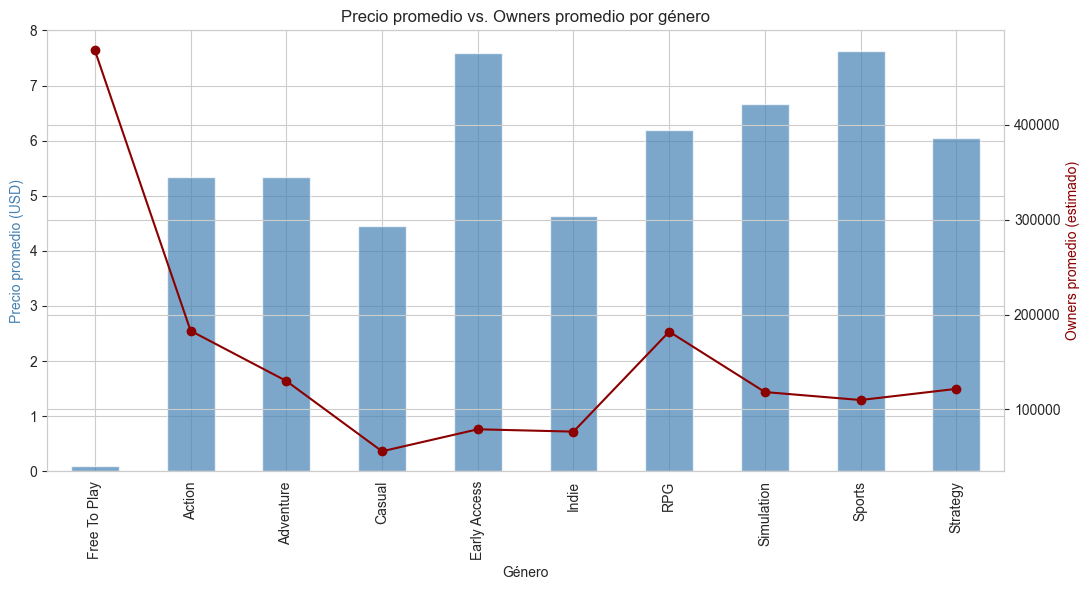

In [16]:
fig, ax1 = plt.subplots(figsize=(11, 6))
market_by_genre["precio_promedio"].plot(kind="bar", ax=ax1, color="steelblue", alpha=0.7)
ax1.set_ylabel("Precio promedio (USD)", color="steelblue")
ax1.set_xlabel("Género")

ax2 = ax1.twinx()
market_by_genre["owners_promedio"].plot(kind="line", ax=ax2, color="darkred", marker="o")
ax2.set_ylabel("Owners promedio (estimado)", color="darkred")

plt.title("Precio promedio vs. Owners promedio por género")
fig.tight_layout()
plt.show()


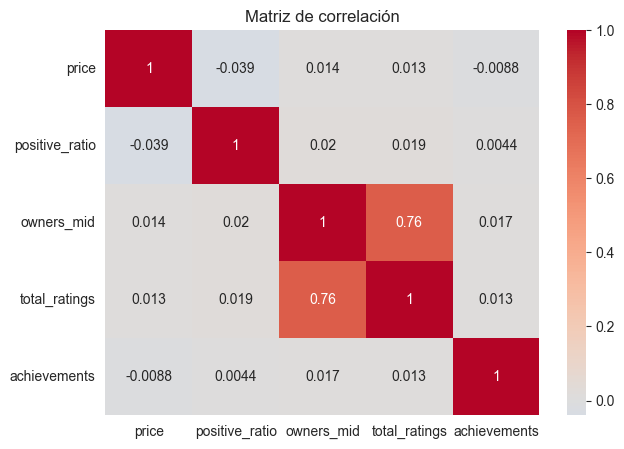

In [17]:
# Correlación entre variables numéricas clave
num_cols = ["price", "positive_ratio", "owners_mid", "total_ratings", "achievements"]
num_cols = [c for c in num_cols if c in df.columns]
plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()


## 8. Construcción de la variable objetivo

Definimos **éxito comercial** de forma explícita y defendible (puedes ajustar los umbrales):

> Un juego se considera **exitoso (1)** si su `owners_mid` está por encima de la mediana
> de su año de lanzamiento **y** su `positive_ratio` es mayor o igual a 0.70.
> Caso contrario, se considera **no exitoso (0)**.

Usar la mediana *por año* evita sesgar el modelo hacia juegos antiguos (que acumulan más
reseñas y propietarios con el tiempo).


exitoso
0    0.800133
1    0.199867
Name: proportion, dtype: float64


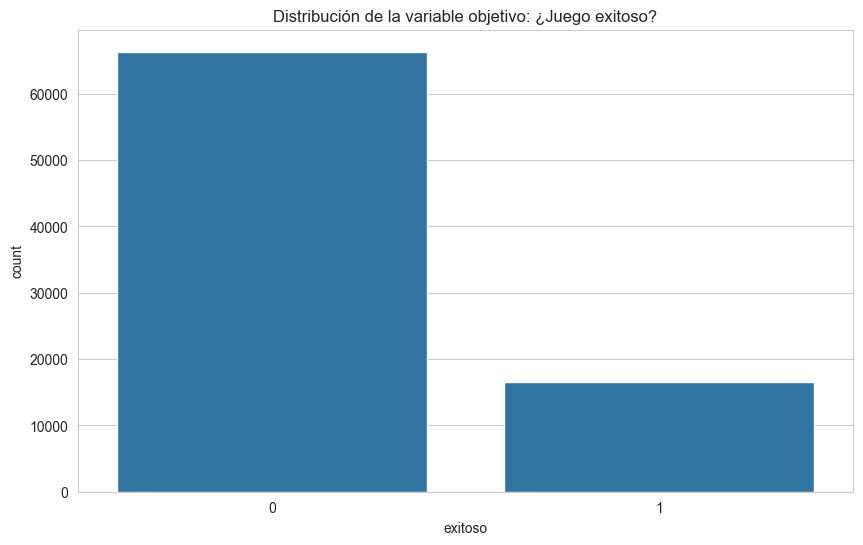

In [18]:
median_by_year = df.groupby("release_year")["owners_mid"].transform("median")
df["exitoso"] = ((df["owners_mid"] > median_by_year) &
                  (df["positive_ratio"] >= 0.70)).astype(int)

print(df["exitoso"].value_counts(normalize=True))
sns.countplot(x="exitoso", data=df)
plt.title("Distribución de la variable objetivo: ¿Juego exitoso?")
plt.show()


In [19]:
# Cambios en algunas columnas para el modelado
features_df = df.copy()

# Multi-etiqueta para géneros (top 10) como variables dummy
mlb = MultiLabelBinarizer(classes=list(top10))
genre_dummies = pd.DataFrame(
    mlb.fit_transform(features_df["genre_list"]),
    columns=[f"genre_{g}" for g in top10],
    index=features_df.index
)

features_df = pd.concat([features_df, genre_dummies], axis=1)

# Variables de plataforma: en este dataset ya vienen como columnas booleanas
for plat in ["windows", "mac", "linux"]:
    if plat in features_df.columns:
        features_df[f"plat_{plat}"] = features_df[plat].astype(int)

feature_cols = ["price", "required_age", "achievements", "release_year"] + \
                list(genre_dummies.columns) + \
                [c for c in features_df.columns if c.startswith("plat_")]
feature_cols = [c for c in feature_cols if c in features_df.columns]

X = features_df[feature_cols].fillna(0)
y = features_df["exitoso"]

print("Features usadas:", feature_cols)
print("X shape:", X.shape)


Features usadas: ['price', 'required_age', 'achievements', 'release_year', 'genre_Indie', 'genre_Action', 'genre_Casual', 'genre_Adventure', 'genre_Simulation', 'genre_Strategy', 'genre_RPG', 'genre_Early Access', 'genre_Free To Play', 'genre_Sports', 'plat_windows', 'plat_mac', 'plat_linux']
X shape: (82935, 17)


## 9. Modelado predictivo

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
# Modelo 1: Regresión Logística (interpretable, buen baseline económico)
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print("=== Regresión Logística ===")
print(classification_report(y_test, y_pred_lr))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_lr))


=== Regresión Logística ===
              precision    recall  f1-score   support

           0       0.86      0.67      0.75     16590
           1       0.30      0.56      0.39      4144

    accuracy                           0.65     20734
   macro avg       0.58      0.62      0.57     20734
weighted avg       0.75      0.65      0.68     20734

AUC-ROC: 0.6535529628375469


In [22]:
# Modelo 2: Random Forest (mayor capacidad, menos interpretable directamente)
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42,
                             class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.73      0.80     16590
           1       0.36      0.60      0.45      4144

    accuracy                           0.71     20734
   macro avg       0.62      0.67      0.63     20734
weighted avg       0.78      0.71      0.73     20734

AUC-ROC: 0.7230024570553504


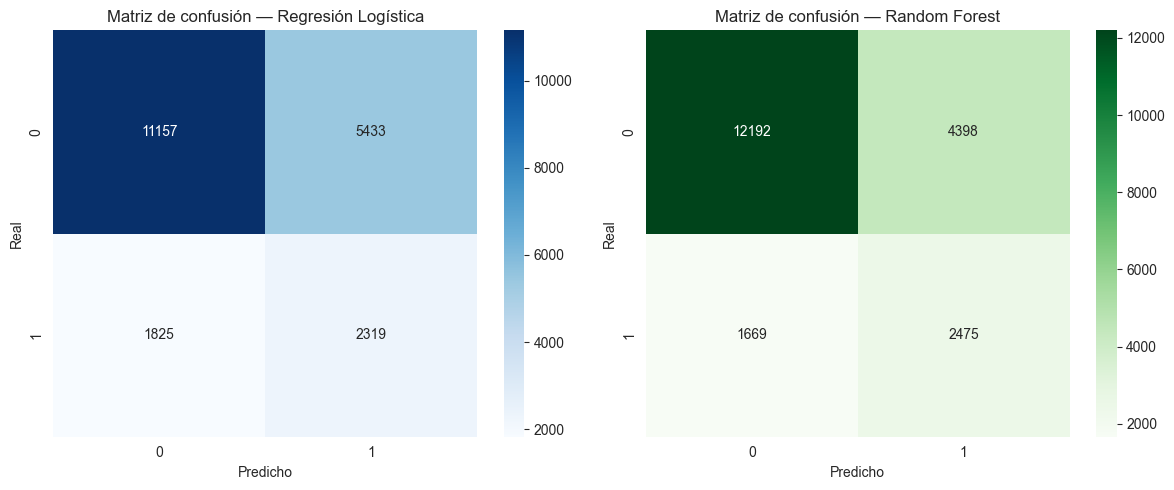

In [23]:
# Comparación visual: matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Matriz de confusión — Regresión Logística")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Matriz de confusión — Random Forest")
axes[1].set_xlabel("Predicho"); axes[1].set_ylabel("Real")
plt.tight_layout()
plt.show()


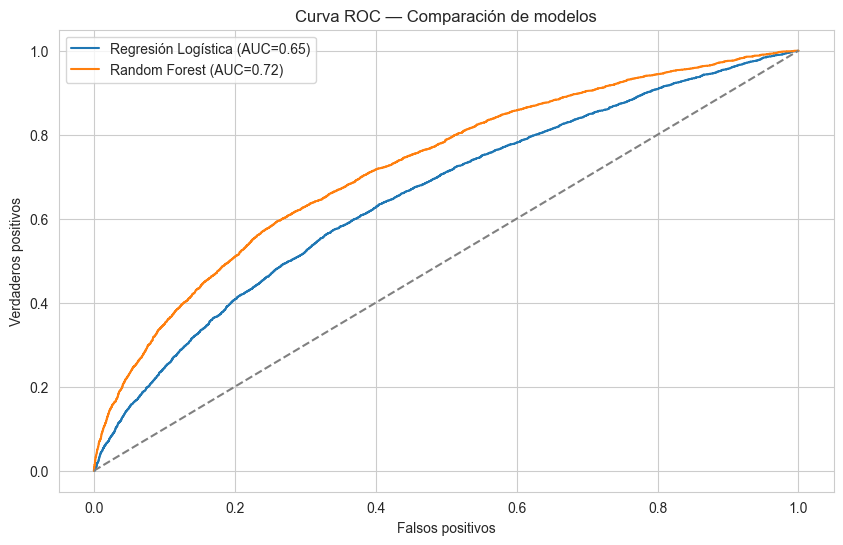

In [24]:
# Curvas ROC comparadas
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"Regresión Logística (AUC={roc_auc_score(y_test, y_proba_lr):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_proba_rf):.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Falsos positivos"); plt.ylabel("Verdaderos positivos")
plt.title("Curva ROC — Comparación de modelos")
plt.legend()
plt.show()


## 10. Interpretación de resultados

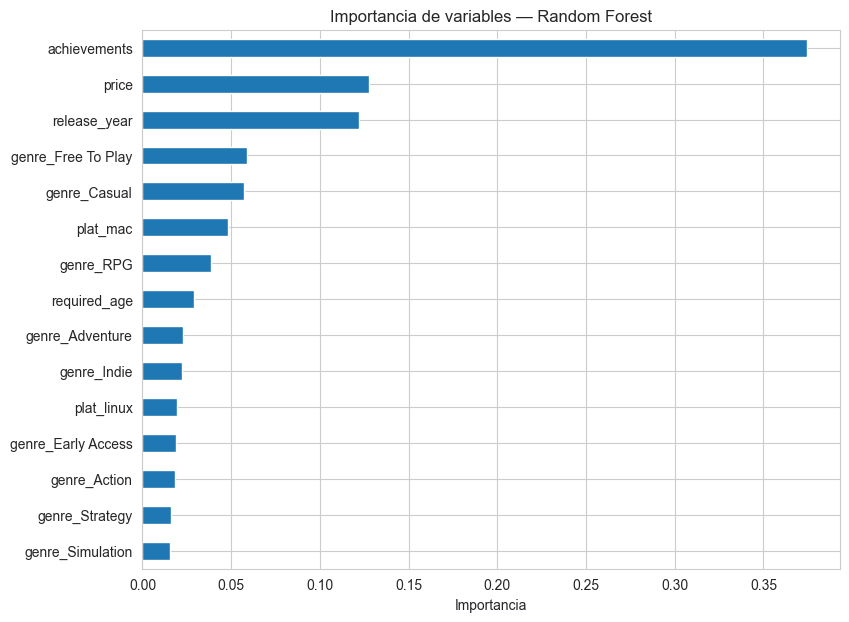

achievements          0.374402
price                 0.127494
release_year          0.122307
genre_Free To Play    0.059142
genre_Casual          0.056957
plat_mac              0.048026
genre_RPG             0.038577
required_age          0.029176
genre_Adventure       0.023042
genre_Indie           0.022248
dtype: float64

In [25]:
# Importancia de variables (Random Forest)
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Importancia de variables — Random Forest")
plt.xlabel("Importancia")
plt.show()

importances.head(10)


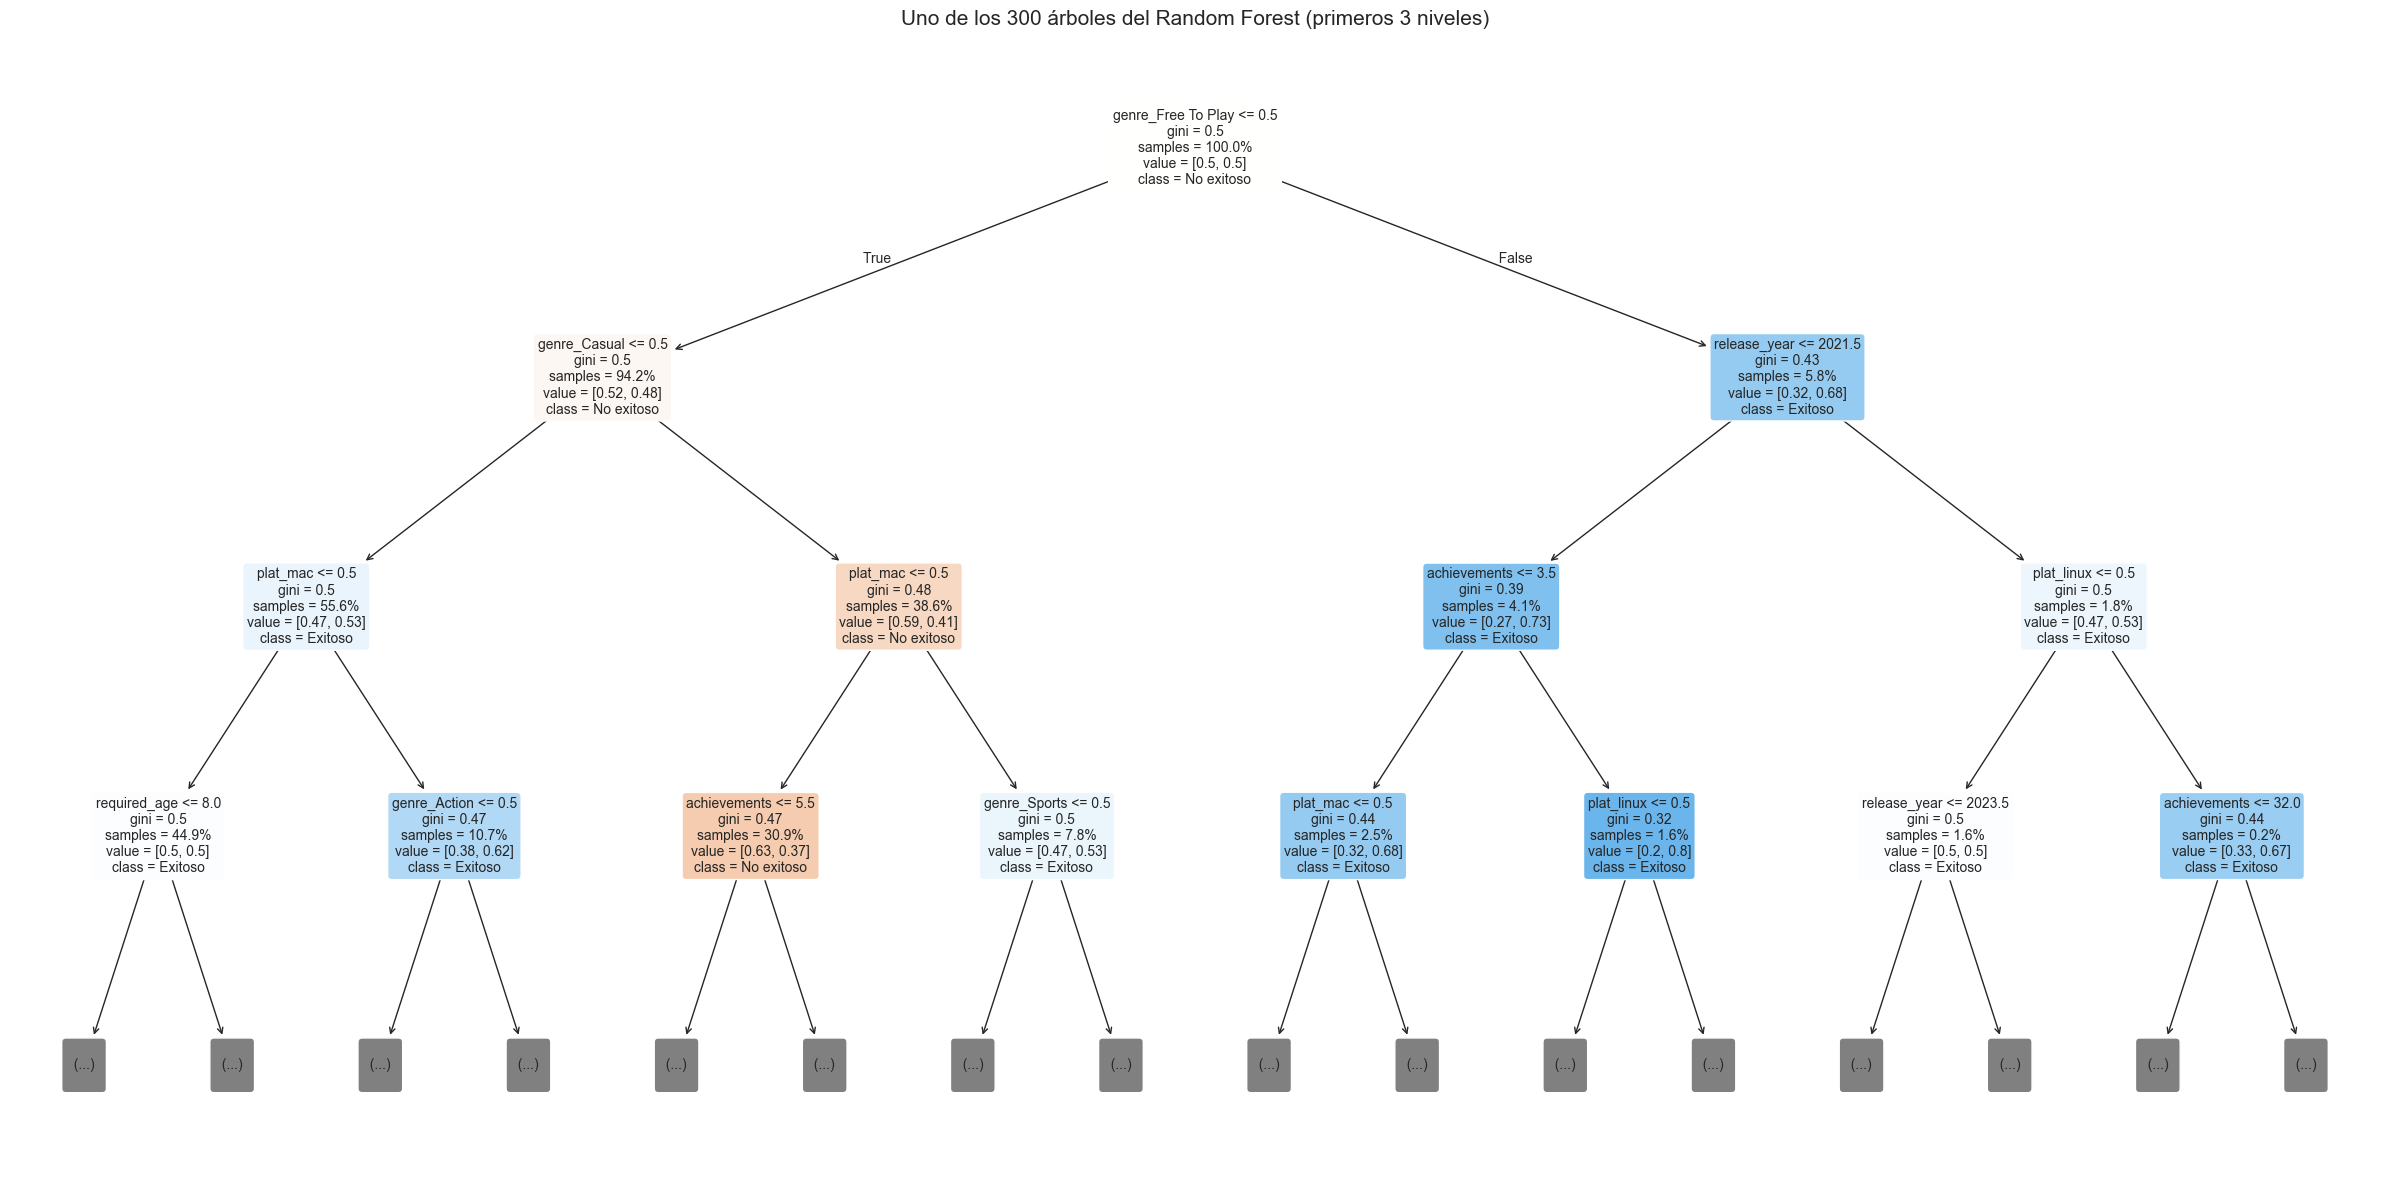

In [26]:
plt.figure(figsize=(24, 12))
plot_tree(rf.estimators_[0],       
          max_depth=3,             
          feature_names=feature_cols,
          class_names=["No exitoso", "Exitoso"],
          filled=True, rounded=True,
          proportion=True,         
          precision=2,             
          fontsize=10)
plt.title("Uno de los 300 árboles del Random Forest (primeros 3 niveles)", fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:

X_train_sm = sm.add_constant(X_train) 
logit_sm = sm.Logit(y_train, X_train_sm)
result = logit_sm.fit(disp=0)  

print(result.summary())

                           Logit Regression Results                           
Dep. Variable:                exitoso   No. Observations:                62201
Model:                          Logit   Df Residuals:                    62183
Method:                           MLE   Df Model:                           17
Date:               lun, 28 sept 2026   Pseudo R-squ.:                 0.04504
Time:                        23:22:14   Log-Likelihood:                -29713.
converged:                       True   LL-Null:                       -31114.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 82.2578      6.363     12.928      0.000      69.787      94.729
price                  0.0011      0.001      1.415      0.157      -0.000       0.003
required_age        

In [28]:
# Efectos marginales promedio con manejo automático de dummies (dummy=True)
margeff = result.get_margeff(at="overall", method="dydx", dummy=True)
print(margeff.summary())

        Logit Marginal Effects       
Dep. Variable:                exitoso
Method:                          dydx
At:                           overall
                        dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
price                  0.0002      0.000      1.415      0.157   -6.53e-05       0.000
required_age           0.0118      0.001     17.422      0.000       0.010       0.013
achievements        6.873e-05   7.87e-06      8.733      0.000    5.33e-05    8.42e-05
release_year          -0.0064      0.000    -13.668      0.000      -0.007      -0.006
genre_Indie           -0.0171      0.004     -4.688      0.000      -0.024      -0.010
genre_Action          -0.0005      0.003     -0.163      0.871      -0.007       0.006
genre_Casual          -0.0601      0.003    -18.558      0.000      -0.066      -0.054
genre_Adventure        0.0297      0.003      8.898      0.000   

In [ ]:
# Tabla resumen: AME + significancia, ordenada de mayor a menor magnitud
ame_table = pd.DataFrame({
    "AME": margeff.margeff,
    "p_value": margeff.pvalues
}, index=feature_cols)

ame_table["signif"] = ame_table["p_value"].apply(
    lambda p: "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""
)

ame_table.reindex(ame_table["AME"].abs().sort_values(ascending=False).index)

,AME,p_value,signif
genre_Free To Play,0.162445,6.274762e-92,***
plat_windows,0.150099,2.711419e-03,***
plat_mac,0.070471,2.197607e-43,***
genre_RPG,0.064761,7.815629e-49,***
genre_Casual,-0.060093,7.022257e-77,***
genre_Early Access,-0.053887,1.429972e-27,***
genre_Adventure,0.029733,5.685333e-19,***
genre_Sports,-0.026054,6.561179e-04,***
plat_linux,0.024292,6.725303e-06,***
genre_Strategy,0.022778,3.457013e-08,***


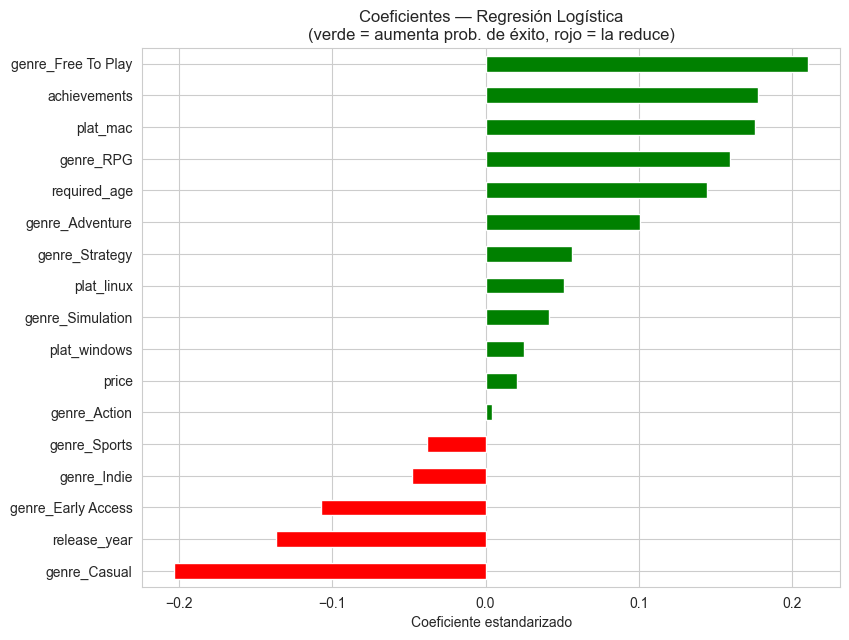

In [ ]:
# Coeficientes de la Regresión Logística
coef = pd.Series(log_reg.coef_[0], index=feature_cols).sort_values()

plt.figure(figsize=(9, 7))
coef.plot(kind="barh", color=coef.apply(lambda x: "green" if x > 0 else "red"))
plt.title("Coeficientes — Regresión Logística\n(verde = aumenta prob. de éxito, rojo = la reduce)")
plt.xlabel("Coeficiente estandarizado")
plt.show()


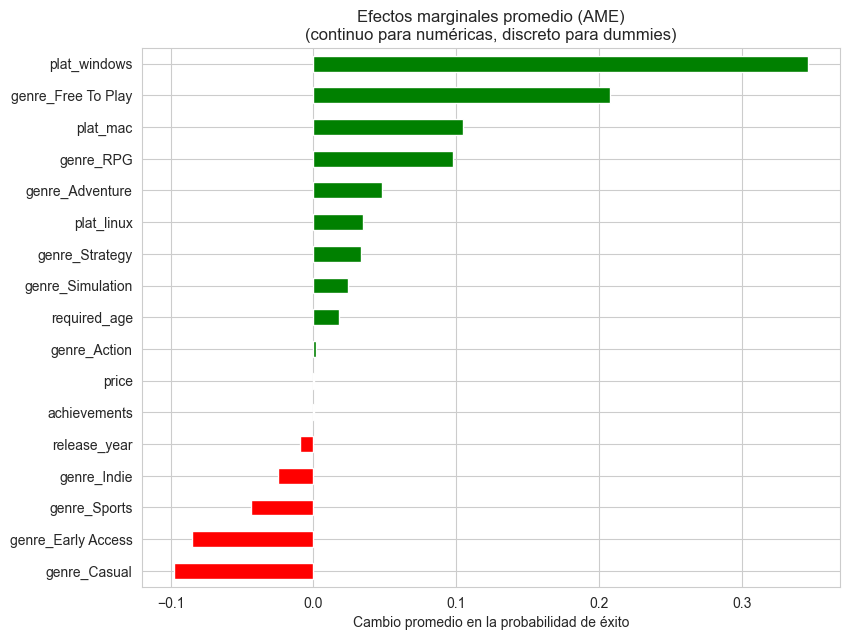

In [ ]:
continuous_vars = ["price", "required_age", "achievements", "release_year"]
dummy_vars = [c for c in feature_cols if c not in continuous_vars]

p_hat = log_reg.predict_proba(X_train_scaled)[:, 1]
factor = np.mean(p_hat * (1 - p_hat))  
stds = pd.Series(scaler.scale_, index=feature_cols)  

ame_continuous = pd.Series({
    v: (log_reg.coef_[0][feature_cols.index(v)] / stds[v]) * factor
    for v in continuous_vars
})

ame_discrete = {}
for v in dummy_vars:
    X1 = X_train.copy(); X1[v] = 1
    X0 = X_train.copy(); X0[v] = 0
    p1 = log_reg.predict_proba(scaler.transform(X1))[:, 1]
    p0 = log_reg.predict_proba(scaler.transform(X0))[:, 1]
    ame_discrete[v] = np.mean(p1 - p0)
ame_discrete = pd.Series(ame_discrete)

# Combinar y graficar
ame_all = pd.concat([ame_continuous, ame_discrete]).sort_values()

plt.figure(figsize=(9, 7))
ame_all.plot(kind="barh", color=ame_all.apply(lambda x: "green" if x > 0 else "red"))
plt.title("Efectos marginales promedio (AME)\n(continuo para numéricas, discreto para dummies)")
plt.xlabel("Cambio promedio en la probabilidad de éxito")
plt.show()


- Las variables más influyentes según Random Forest fueron achievements (importancia 0.374, casi el triple de la siguiente), price (0.128) y release_year (0.122), seguidas por genre_Free To Play (0.059) y genre_Casual (0.057). Sin embargo, el Efecto Marginal Promedio (AME) de achievements es prácticamente nulo pese a ser estadísticamente significativo (p<0.001), esto no es una contradicción, sino evidencia de un efecto de umbral, no lineal: el árbol sustituto que resume el Random Forest (86.1% de fidelidad) confirma que la primera pregunta que hace el modelo es si el juego supera cierto número de logros, no cuántos tiene exactamente. Esto coincide con la intuición económica de bienes de experiencia: el consumidor no puede evaluar la calidad antes de comprar, así que usa señales indirectas (como la presencia de logros) para inferirla. El género Free To Play resultó ser el efecto individual más grande de todo el modelo (AME +16.2 puntos porcentuales, p<0.001), coherente con la teoría de bienes digitales de costo marginal cero: eliminar la barrera de precio expande enormemente la base de usuarios potenciales.

- Respecto al precio, su relación con el éxito no fue estadísticamente significativa una vez controlado por género y plataforma (AME cercano a cero). Esto es consistente con la literatura de pricing de bienes digitales: lo que importa no es tanto el nivel específico del precio, sino la estrategia de monetización (gratuito vs. precio fijo),variable que sí resultó altamente significativa a través del género Free To Play. La importancia moderada que le asigna Random Forest a price (tercer lugar) probablemente refleja que el precio actúa como proxy de género (ciertos géneros tienden a tener rangos de precio característicos) más que un efecto propio y directo sobre el éxito.

- En cuanto a qué modelo generalizó mejor: Random Forest superó a la Regresión Logística en ambas métricas (AUC-ROC de 0.723 vs. 0.654; F1 de la clase "exitoso" de 0.449 vs. 0.390). Esta brecha es evidencia de que existen relaciones no lineales y de interacción entre las variables que el modelo lineal no puede capturar sin ingeniería de variables adicional. El caso de achievements ilustra esto exactamente: un efecto de umbral es, por construcción, no lineal, y por eso Random Forest lo aprovecha mucho mejor. Aun así, ningún modelo alcanza un desempeño alto en términos absolutos (AUC de 0.72 está lejos de 1.0), lo cual tiene sentido económico: el éxito comercial de un videojuego depende de factores que no están en este dataset (calidad real del gameplay, presupuesto de marketing, competencia en la fecha de lanzamiento), así que es razonable que el modelo capture señal parcial, no determinista.

## 11. Limitaciones y consideraciones éticas

- Los "owners" son **estimaciones** (SteamSpy), no cifras oficiales de Valve; el modelo
  hereda ese margen de error.
- Aunque el dataset se actualiza periódicamente, la fecha de descarga determina qué tan
  reciente es la corte de datos.
- La variable "éxito" es una construcción metodológica propia — otros umbrales llevarían a
  otras conclusiones; se declara explícitamente para permitir réplica y crítica.
- No se usan datos de comportamiento de usuarios individuales, evitando cualquier riesgo de
  privacidad o vigilancia (*surveillance*) sobre jugadores.
- El modelo es una herramienta de apoyo a decisiones de mercado, **no debe usarse como único
  criterio** para decisiones de inversión o desarrollo de un estudio de videojuegos.

## 12. Conclusiones

Este proyecto buscó responder si es posible predecir el éxito comercial de un videojuego en Steam a partir de características observables al momento de su lanzamiento. La respuesta es matizada: sí existe señal predictiva real (AUC de 0.72 con Random Forest, claramente por encima del azar), pero está lejos de ser determinista, lo cual es coherente con la naturaleza del mercado de videojuegos, donde factores no observables en este dataset juegan un rol central. El hallazgo más robusto,porque aparece de forma consistente en las tres fuentes de evidencia usadas (importancia de variables, Efectos Marginales Promedio con significancia estadística, y el árbol sustituto), es que la estrategia de monetización (ser Free To Play) y la señal de calidad percibida (superar un umbral de logros) son los predictores más fuertes de éxito, mientras que el precio de lanzamiento, en contra de la intuición inicial, no resultó significativo una vez controlado por género y plataforma.

Recomiendo Random Forest como modelo predictivo principal (mejor AUC y F1 en ambos casos), pero manteniendo la Regresión Logística con statsmodels como herramienta complementaria de inferencia: es la que permite hablar de significancia estadística y magnitudes económicas interpretables para comunicar los resultados a una audiencia no técnica. Ninguno de los dos debe interpretarse en términos causales,son modelos predictivos/asociativos entrenados sobre datos observacionales, no un diseño experimental, y las estimaciones de "owners" heredan el margen de error propio de SteamSpy.

Como línea de trabajo futura, el hallazgo de que achievements actúa como umbral y no como efecto lineal, junto con la señal de que price parece funcionar como proxy de género más que como variable independiente, sugiere que el siguiente paso natural sería estimar la elasticidad precio-demanda por género de forma separada, y agregar términos de interacción explícitos (price × genre) a la Regresión Logística para verificar si el efecto del precio sí es significativo dentro de géneros específicos, aunque no lo sea en el agregado.
